#  Regresie — Predicția Prețului Locuințelor

## Definirea Problemei

**Problema abordată:** Predicția prețului de vânzare al unei locuințe pe baza
caracteristicilor sale fizice și localizării.

**Variabila de ieșire:** `price` — prețul locuinței în USD. Interval: ~80.000$ — 1.500.000$.

**Variabile de intrare:** suprafața locuibilă, lot, număr dormitoare, băi, etaje,
vedere la apă, vederi, condiție, calitate construcție, an construcție, renovare, etc.

**Relevanță practică:** Estimarea corectă a prețului imobiliar ajută cumpărătorii,
vânzătorii și agențiile imobiliare în luarea deciziilor.

**De ce am ales:** Dataset-ul este realist, cu caracteristici intuitive care permit
o analiză SHAP bogată și interpretabilă.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import joblib, os, shap

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor

sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
os.makedirs('../models', exist_ok=True); os.makedirs('../plots', exist_ok=True)

In [2]:
df = pd.read_csv('../data/house_prices.csv')
print(f"Shape: {df.shape}"); display(df.head()); display(df.describe().round(0))
print(f"Valori lipsă: {df.isnull().sum().sum()}")

Shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.0,21613.0,21613.0,21613.0,21613.0,21613.0,21613.0,21613.0,21613.0,21613.0,21613.0,21613.0,21613.0,21613.0,21613.0,21613.0,21613.0,21613.0,21613.0
mean,4.580302e+09,540088.0,3.0,2.0,2080.0,15107.0,1.0,0.0,0.0,3.0,8.0,1788.0,292.0,1971.0,84.0,98078.0,48.0,-122.0,1987.0,12768.0
std,2.876566e+09,367127.0,1.0,1.0,918.0,41421.0,1.0,0.0,1.0,1.0,1.0,828.0,443.0,29.0,402.0,54.0,0.0,0.0,685.0,27304.0
min,1.000102e+06,75000.0,0.0,0.0,290.0,520.0,1.0,0.0,0.0,1.0,1.0,290.0,0.0,1900.0,0.0,98001.0,47.0,-123.0,399.0,651.0
25%,2.123049e+09,321950.0,3.0,2.0,1427.0,5040.0,1.0,0.0,0.0,3.0,7.0,1190.0,0.0,1951.0,0.0,98033.0,47.0,-122.0,1490.0,5100.0
50%,3.904930e+09,450000.0,3.0,2.0,1910.0,7618.0,2.0,0.0,0.0,3.0,7.0,1560.0,0.0,1975.0,0.0,98065.0,48.0,-122.0,1840.0,7620.0
75%,7.308900e+09,645000.0,4.0,2.0,2550.0,10688.0,2.0,0.0,0.0,4.0,8.0,2210.0,560.0,1997.0,0.0,98118.0,48.0,-122.0,2360.0,10083.0
max,9.900000e+09,7700000.0,33.0,8.0,13540.0,1651359.0,4.0,1.0,4.0,5.0,13.0,9410.0,4820.0,2015.0,2015.0,98199.0,48.0,-121.0,6210.0,871200.0


Valori lipsă: 0


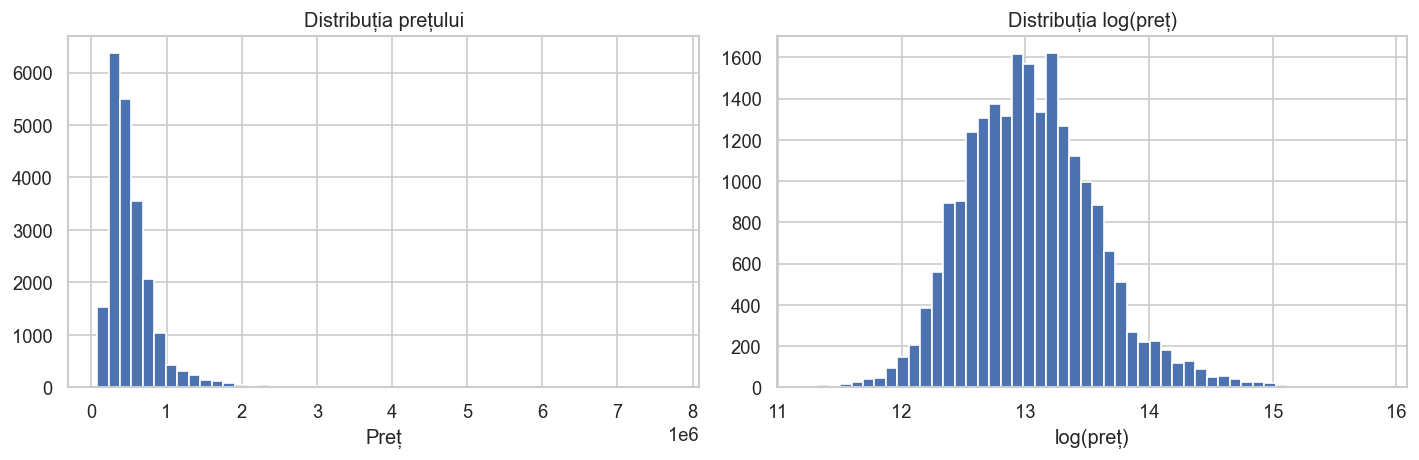

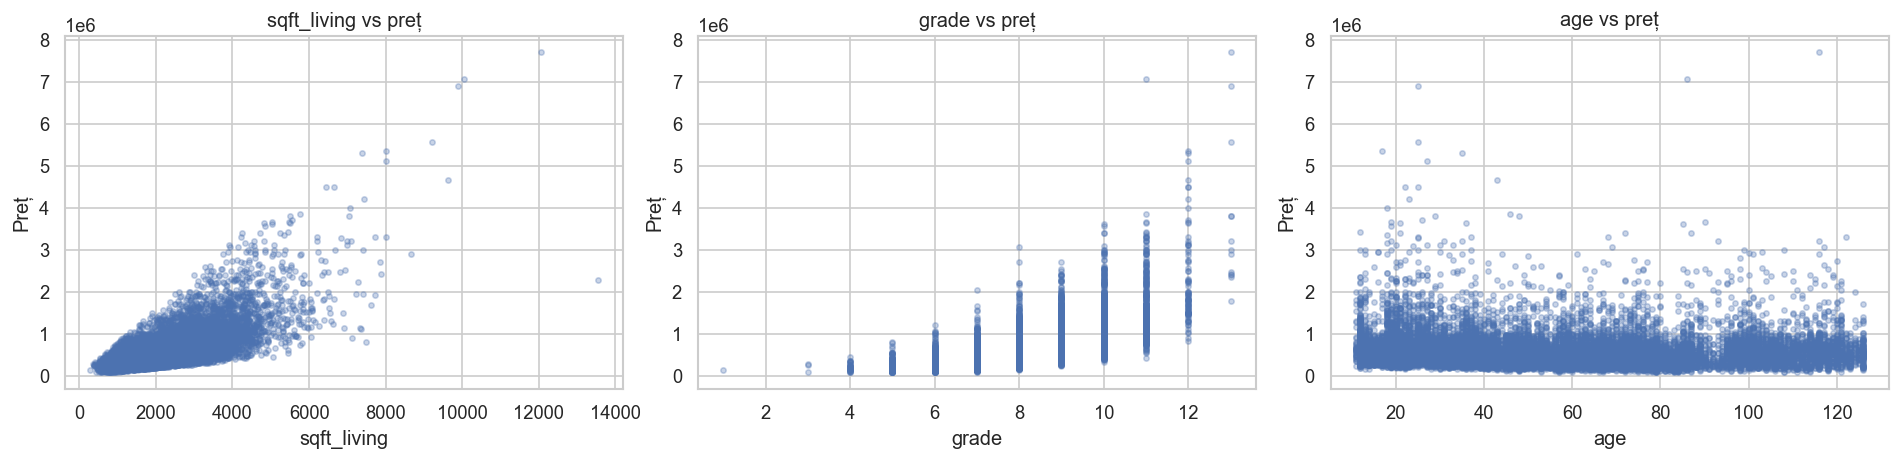

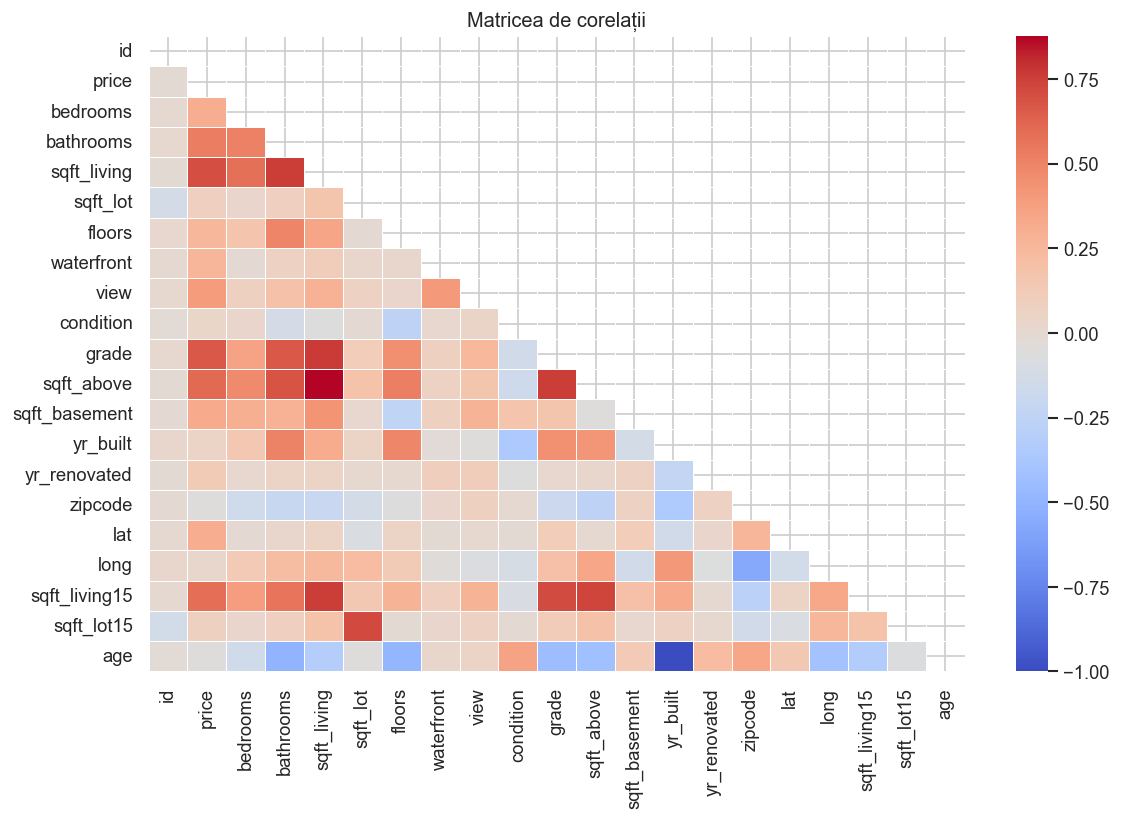

In [3]:
df['age'] = 2026 - df['yr_built']

#distributia pretului
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price'], bins=50)
axes[0].set_title('Distribuția prețului')
axes[0].set_xlabel('Preț')

axes[1].hist(np.log1p(df['price']), bins=50)
axes[1].set_title('Distribuția log(preț)')
axes[1].set_xlabel('log(preț)')

plt.tight_layout()
plt.savefig('../plots/reg_price_distribution.png')
plt.show()

#relatii variabile vs pret
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['sqft_living', 'grade', 'age']):
    ax.scatter(df[col], df['price'], s=10, alpha=0.3)
    ax.set_title(f'{col} vs preț')
    ax.set_xlabel(col)
    ax.set_ylabel('Preț')

plt.tight_layout()
plt.savefig('../plots/reg_scatter.png')
plt.show()

#corelatii
plt.figure(figsize=(10, 7))

corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    linewidths=0.3,
    annot=False
)

plt.title('Matricea de corelații')
plt.tight_layout()
plt.savefig('../plots/reg_correlation.png')
plt.show()


### Analiză Exploratorie (EDA)
1. Distribuția Prețului

Problema: Prețul inițial este puternic asimetric (multe case ieftine, câteva extrem de scumpe).

Soluția: Aplicarea log(preț) transformă distribuția într-una normală, facilitând învățarea modelelor de regresie.

2. Corelații și Relații Cheie

sqft_living: Cea mai puternică relație liniară; pe măsură ce suprafața crește, prețul urcă constant.

grade: Influență majoră; calitatea construcției (grade > 10) generează o creștere exponențială a valorii.

age: Vârsta casei nu are o relație liniară simplă; există interes ridicat atât pentru clădiri noi, cât și pentru cele istorice.

3. Matricea de Corelație

Predictori principali: sqft_living și grade sunt cei mai corelați cu prețul.

Multicoliniaritate: Există redundanță între sqft_living și sqft_above, aspect ce trebuie gestionat în selecția variabilelor.

Concluzie: Modelul se va baza în principal pe suprafață și calitate, utilizând variabila logaritmată pentru a asigura stabilitatea predicțiilor.

In [4]:
X = df.drop('price', axis=1)
y = df['price']

if 'date' in X.columns:
    X = X.drop('date', axis=1)

object_cols = X.select_dtypes(include=['object']).columns.tolist()
if object_cols:
    X = X.drop(columns=object_cols)

X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

joblib.dump(scaler, '../models/reg_scaler.pkl')
joblib.dump(X.columns.tolist(), '../models/reg_features.pkl')

models_reg = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'SVR': SVR(kernel='rbf', C=1.0, cache_size=500),
    'KNN Regressor': KNeighborsRegressor(n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_estimators=100, tree_method='hist'),
    'CatBoost': CatBoostRegressor(random_state=RANDOM_STATE, verbose=0, iterations=100),
    'EBM Regressor': ExplainableBoostingRegressor(random_state=RANDOM_STATE, max_rounds=100, interactions=5),
    'Gaussian Process': GaussianProcessRegressor(random_state=RANDOM_STATE, n_restarts_optimizer=5),
}

results_reg = []
trained_reg = {}

for name, model in models_reg.items():
    needs_sc = name in ['Linear Regression', 'SVR', 'KNN Regressor']
    X_tr = X_train_sc if needs_sc else X_train.values
    X_te = X_test_sc if needs_sc else X_test.values

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    mse = mean_squared_error(y_test, y_pred)

    results_reg.append({
        'Model': name,
        'MSE': round(mse, 0),
        'MAE': round(mean_absolute_error(y_test, y_pred), 0),
        'RMSE': round(np.sqrt(mse), 0),
        'R²': round(r2_score(y_test, y_pred), 4),
    })

    trained_reg[name] = (model, needs_sc)

results_df_reg = pd.DataFrame(results_reg).sort_values('R²', ascending=False).reset_index(drop=True)

display(results_df_reg.style.background_gradient(cmap='RdYlGn', subset=['R²']))

top5_reg = results_df_reg.head(5)['Model'].tolist()
print(top5_reg)


,Model,MSE,MAE,RMSE,R²
0,CatBoost,16056272078.000000,70602.000000,126713.000000,0.892700
1,Random Forest,19719526028.000000,72308.000000,140426.000000,0.868200
2,XGBoost,20568450476.000000,72118.000000,143417.000000,0.862500
3,EBM Regressor,30771423036.000000,100174.000000,175418.000000,0.794300
4,KNN Regressor,30929953297.000000,93823.000000,175869.000000,0.793200
5,Decision Tree,38662403715.000000,104444.000000,196628.000000,0.741500
6,Linear Regression,44147960824.000000,126536.000000,210114.000000,0.704900
7,SVR,158848812503.000000,229151.000000,398558.000000,-0.061900
8,Gaussian Process,447329571852.000000,544356.000000,668827.000000,-1.990400


['CatBoost', 'Random Forest', 'XGBoost', 'EBM Regressor', 'KNN Regressor']


# Rezultate Modele de Regresie

### 1. Performanța Modelelor
Performanța a fost evaluată folosind metricul R^2:

* CatBoost: 0.8927 (cel mai bun scor, erori MAE și RMSE minime)
* Random Forest: > 0.86
* XGBoost: > 0.86
* EBM: ~0.79
* KNN: ~0.79
* SVR: Scor negativ (necesită reconfigurare)

### 2. Modele selectate pentru optimizare
Următoarele modele vor trece în etapa de tuning:
1. CatBoost
2. Random Forest
3. XGBoost
4. EBM Regressor
5. KNN Regressor

### Concluzie
Algoritmii de tip Boosting și Ensemble sunt cei mai eficienți pentru acest set de date, reușind să captureze cu precizie complexitatea prețurilor imobiliare.

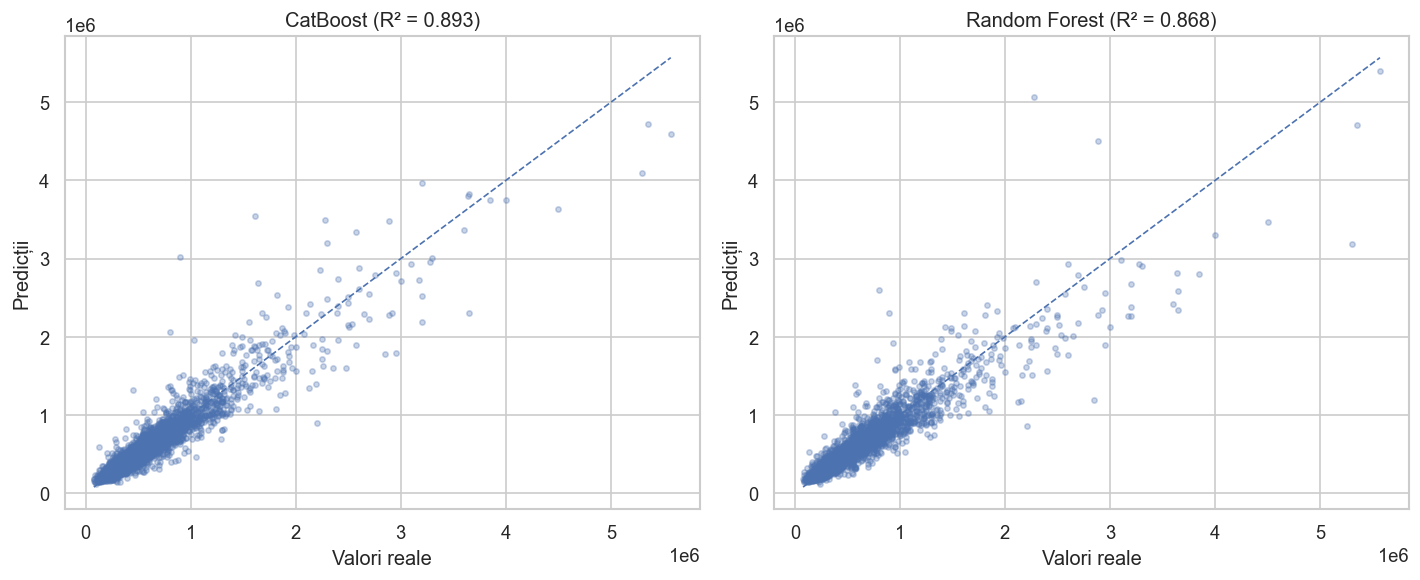

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, name in enumerate(top5_reg[:2]):
    model, needs_sc = trained_reg[name]

    X_te = X_test_sc if needs_sc else X_test.values
    y_pred = model.predict(X_te)

    axes[idx].scatter(y_test, y_pred, s=10, alpha=0.3)

    mn, mx = y_test.min(), y_test.max()
    axes[idx].plot([mn, mx], [mn, mx], '--', linewidth=1)

    r2 = r2_score(y_test, y_pred)
    axes[idx].set_title(f'{name} (R² = {r2:.3f})')
    axes[idx].set_xlabel('Valori reale')
    axes[idx].set_ylabel('Predicții')

plt.tight_layout()
plt.savefig('../plots/reg_pred_vs_actual.png')
plt.show()

## Analiza Vizuală: Valori Reale vs. Predicții

Graficele de tip scatter plot de mai sus compară valorile reale ale proprietăților cu predicțiile generate de cele mai performante două modele (CatBoost și Random Forest).

### Observații cheie:
* Alinierea punctelor: Majoritatea punctelor sunt grupate strâns în jurul liniei diagonale (linia de referință pentru predicția perfectă), ceea ce indică o acuratețe ridicată.
* Distribuția erorilor: Modelele performează excelent pentru segmentul principal de prețuri, cu o ușoară dispersie în zona proprietăților de lux (valori foarte mari).
* Coerență: CatBoost (R² = 0.893) prezintă o concentrare mai liniară a punctelor față de Random Forest, confirmând poziția sa de lider în topul performanței.

In [6]:
param_grids_reg = {
    'CatBoost': {
        'iterations': [100, 200, 300],
        'depth': [4, 6, 8],
        'learning_rate': [0.03, 0.05, 0.1],
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1],
    },
    'EBM Regressor': {
        'max_rounds': [100, 200],
        'interactions': [5, 10],
        'learning_rate': [0.01, 0.05],
    },
    'KNN Regressor': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
    }
}

top5_reg = ['CatBoost', 'Random Forest', 'XGBoost', 'EBM Regressor', 'KNN Regressor']

model_constructors_reg = {
    'CatBoost': CatBoostRegressor(random_state=RANDOM_STATE, verbose=0),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
    'EBM Regressor': ExplainableBoostingRegressor(random_state=RANDOM_STATE),
    'KNN Regressor': KNeighborsRegressor(),
}

tuned_reg = {}; tuning_reg_results = []
for name in top5_reg:
    if name not in param_grids_reg: continue
    needs_sc = name in ['KNN Regressor']
    X_tr = X_train_sc if needs_sc else X_train.values
    X_te = X_test_sc if needs_sc else X_test.values
    gs = GridSearchCV(model_constructors_reg[name], param_grids_reg[name],
                      cv=5, scoring='r2', n_jobs=-1)
    gs.fit(X_tr, y_train)
    best = gs.best_estimator_; y_pred = best.predict(X_te)
    mse = mean_squared_error(y_test, y_pred)
    tuning_reg_results.append({
        'Model': name, 'CV R²': round(gs.best_score_, 4),
        'Test R²': round(r2_score(y_test, y_pred), 4),
        'RMSE': round(np.sqrt(mse), 0),
        'MAE': round(mean_absolute_error(y_test, y_pred), 0),
    })
    tuned_reg[name] = (best, needs_sc)
    joblib.dump(best, f'../models/reg_{name.replace(" ","_").lower()}_tuned.pkl')
    print(f" {name} — R²: {tuning_reg_results[-1]['Test R²']:.4f}")

display(pd.DataFrame(tuning_reg_results).sort_values('Test R²', ascending=False))

 CatBoost — R²: 0.9017
 Random Forest — R²: 0.8688
 XGBoost — R²: 0.8760
 EBM Regressor — R²: 0.8415
 KNN Regressor — R²: 0.7890


,Model,CV R²,Test R²,RMSE,MAE
0,CatBoost,0.8961,0.9017,121238.0,67237.0
2,XGBoost,0.8943,0.8760,136218.0,69660.0
1,Random Forest,0.8753,0.8688,140114.0,72139.0
3,EBM Regressor,0.8546,0.8415,153985.0,86374.0
4,KNN Regressor,0.7827,0.7890,177664.0,92047.0


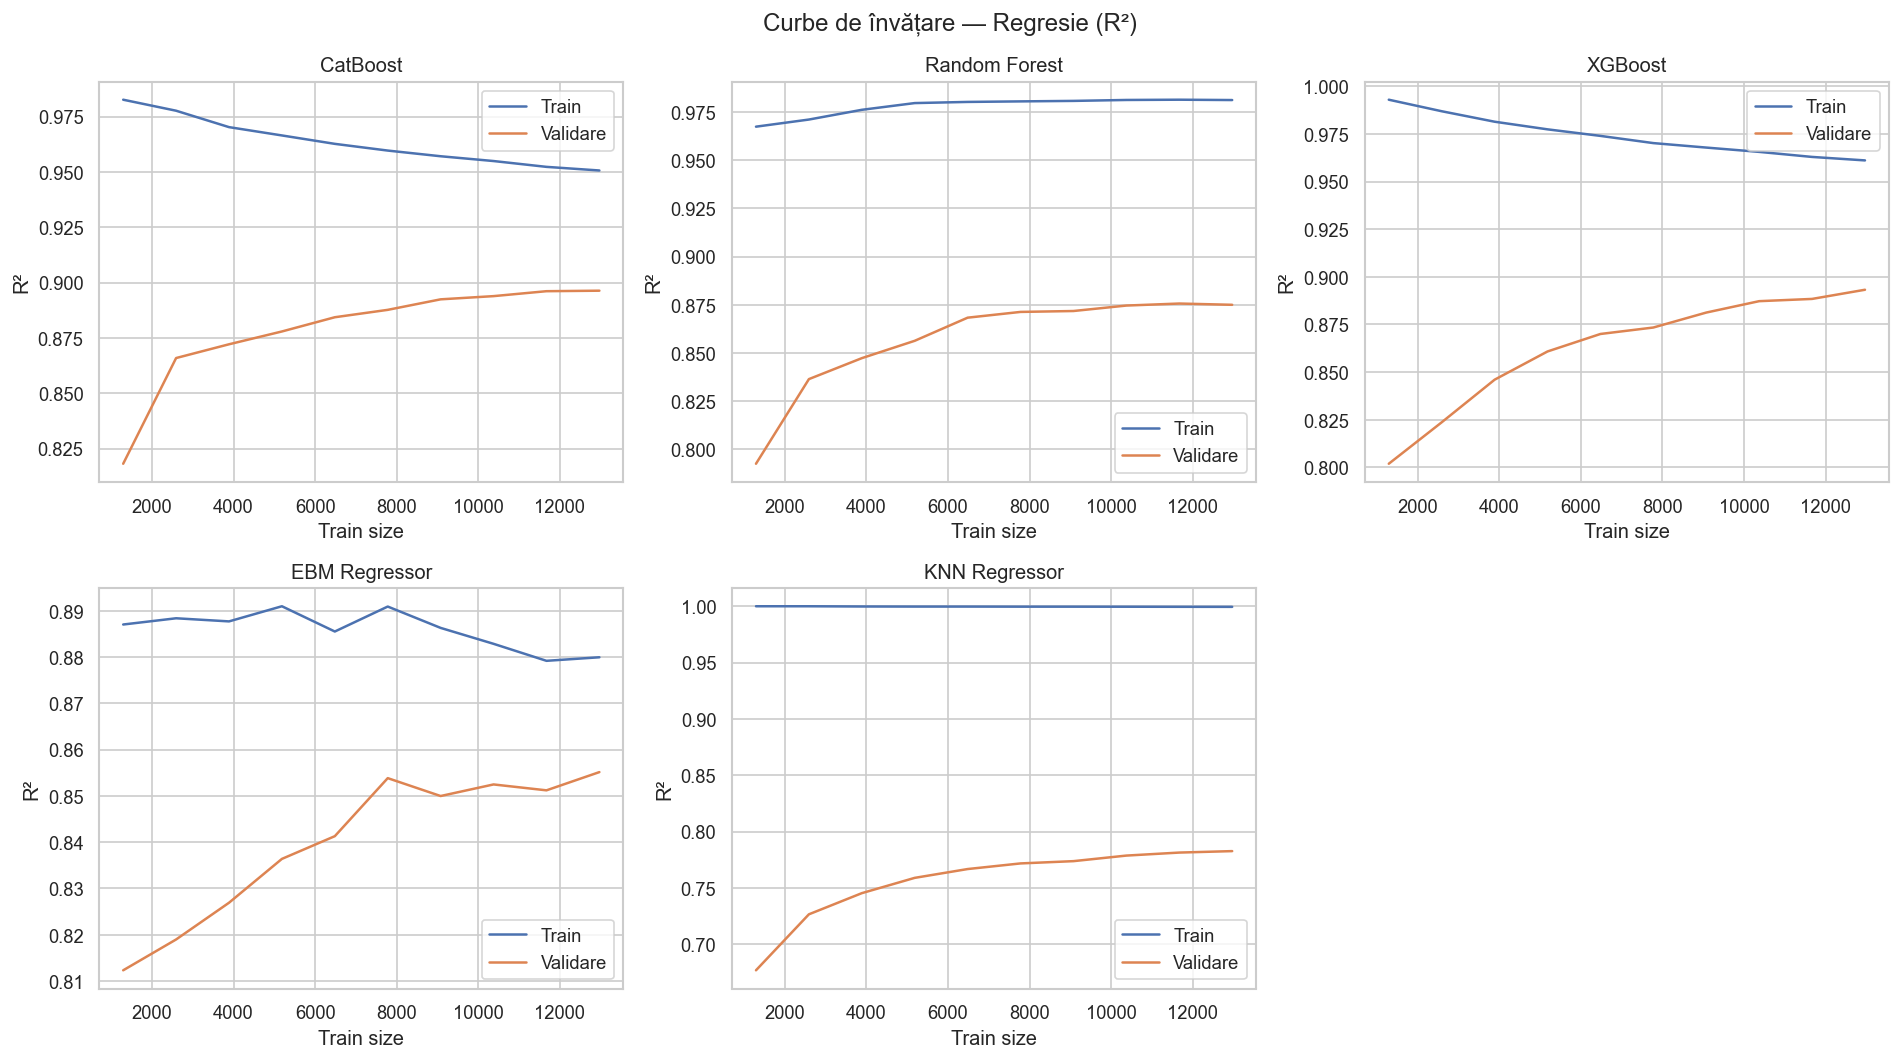

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, (name, (model, needs_scaling)) in enumerate(list(tuned_reg.items())[:5]):
    X_use = X_train_sc if needs_scaling else X_train.values

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_use,
        y_train,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2'
    )

    tr_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    ax = axes[idx]

    ax.plot(train_sizes, tr_mean, label='Train')
    ax.plot(train_sizes, val_mean, label='Validare')

    ax.set_title(name)
    ax.set_xlabel('Train size')
    ax.set_ylabel('R²')
    ax.legend()

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Curbe de învățare — Regresie (R²)')
plt.tight_layout()

plt.savefig('../plots/reg_learning_curves.png')
plt.show()

## Analiza Curbelor de Învățare

Graficele de mai jos ilustrează evoluția scorului R² în funcție de dimensiunea setului de date pentru principalele modele testate.

### Observații principale

*   **Convergența scorurilor**: Pentru majoritatea modelelor (CatBoost, XGBoost, Random Forest), se observă o apropiere progresivă între curba de antrenare și cea de validare pe măsură ce volumul de date crește.
*   **Capacitatea de generalizare**: Scorurile de validare tind să se stabilizeze în partea superioară a graficului (R² > 0.85 pentru modelele de tip boosting), ceea ce confirmă faptul că modelele nu suferă de un overfitting sever.
*   **KNN Regressor**: Se observă un comportament specific unde scorul de antrenare rămâne perfect (1.0), în timp ce validarea urcă lent spre 0.78, sugerând o sensibilitate mai mare la zgomotul din date față de algoritmii bazați pe arbori.
*   **Potențial de scalare**: Panta ascendentă a curbelor de validare la finalul axei X sugerează că performanța ar putea fi îmbunătățită și mai mult prin adăugarea de date suplimentare.



SHAP pentru regresie: CatBoost


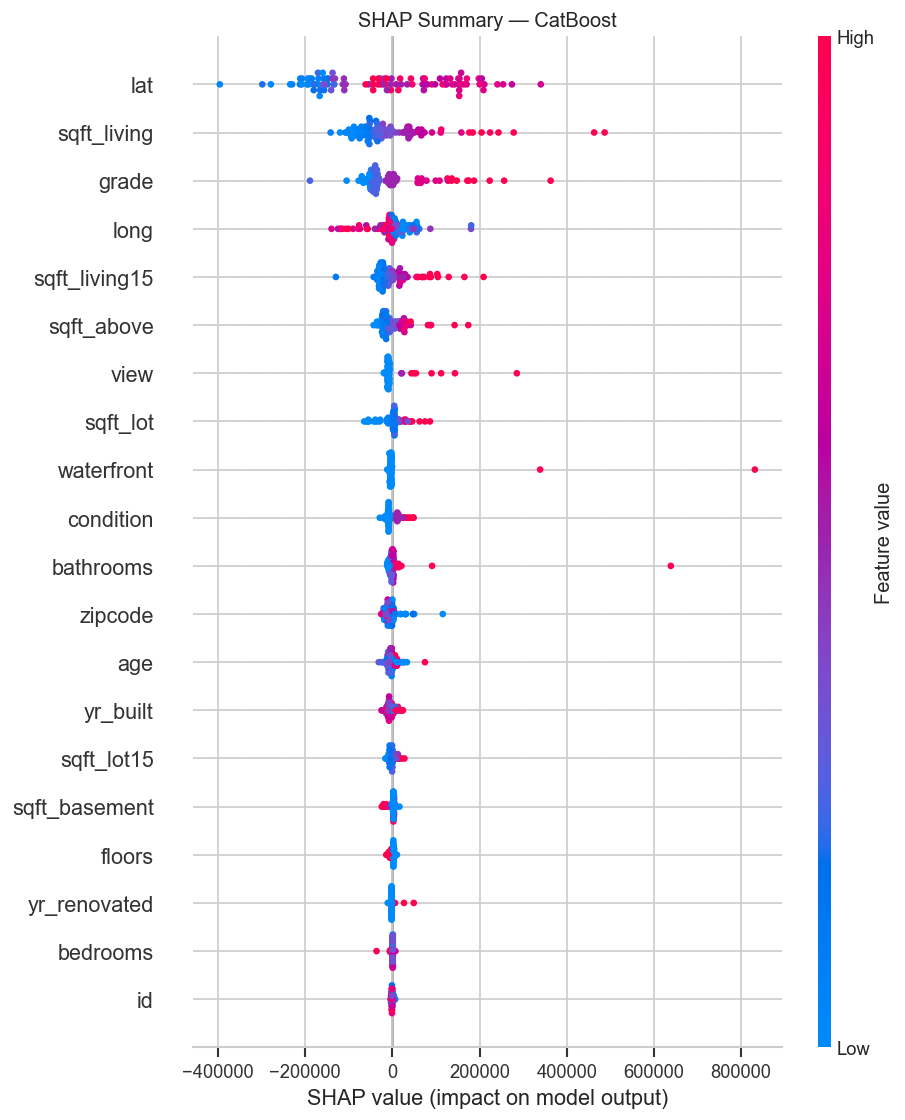

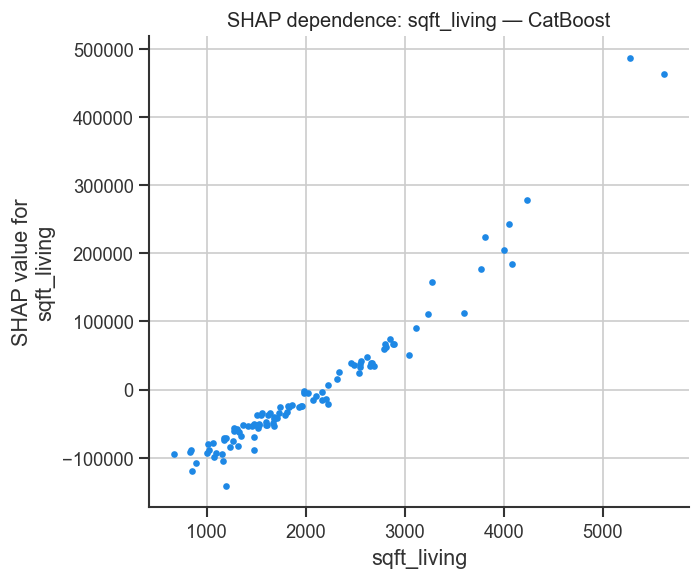

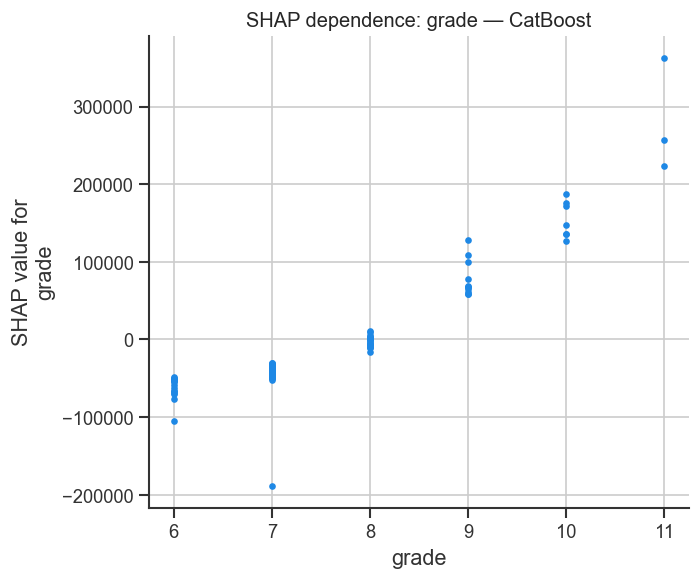

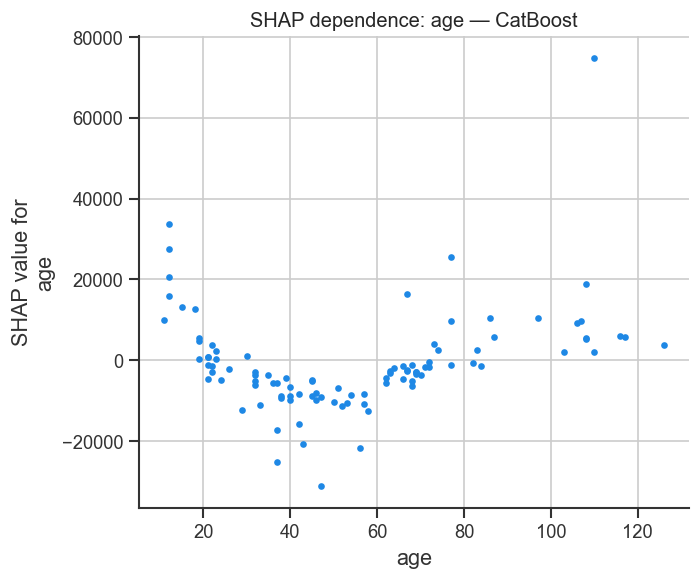

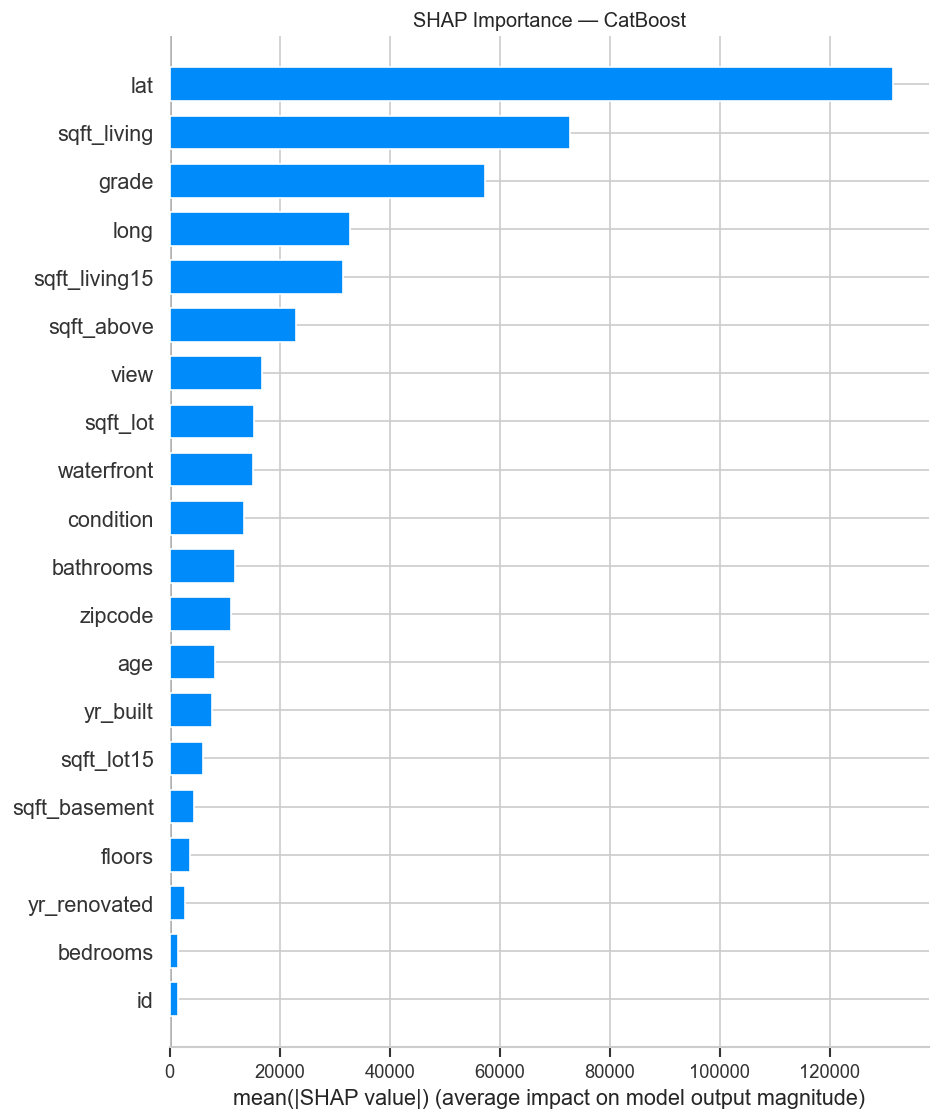

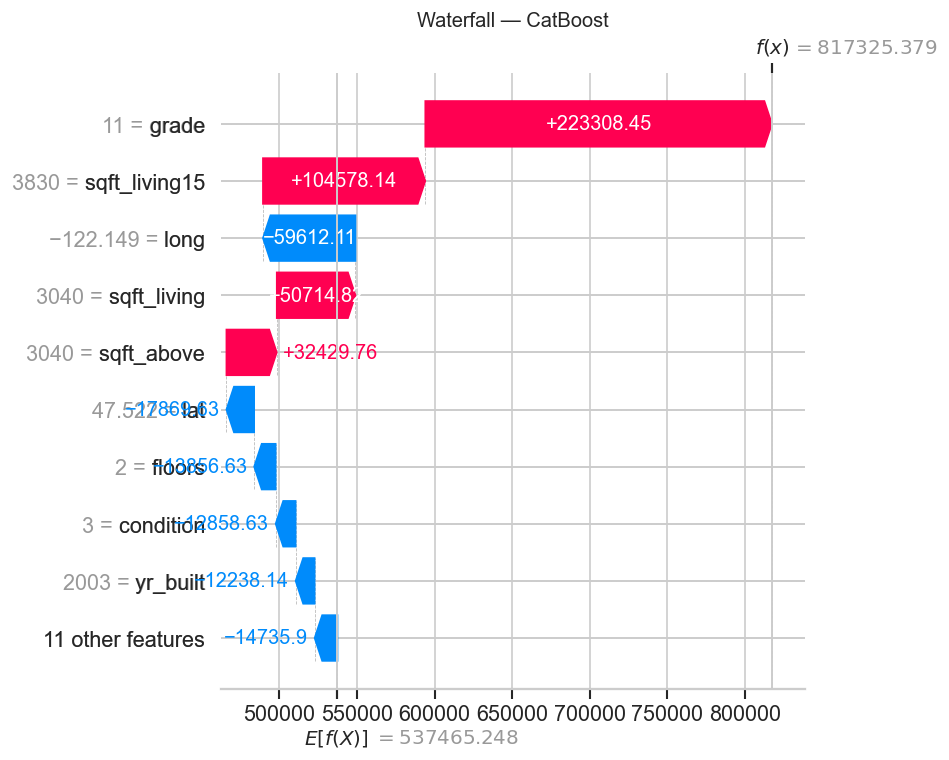

Top 3 features (global): [np.str_('lat'), np.str_('sqft_living'), np.str_('grade')]

SHAP pentru regresie: Random Forest


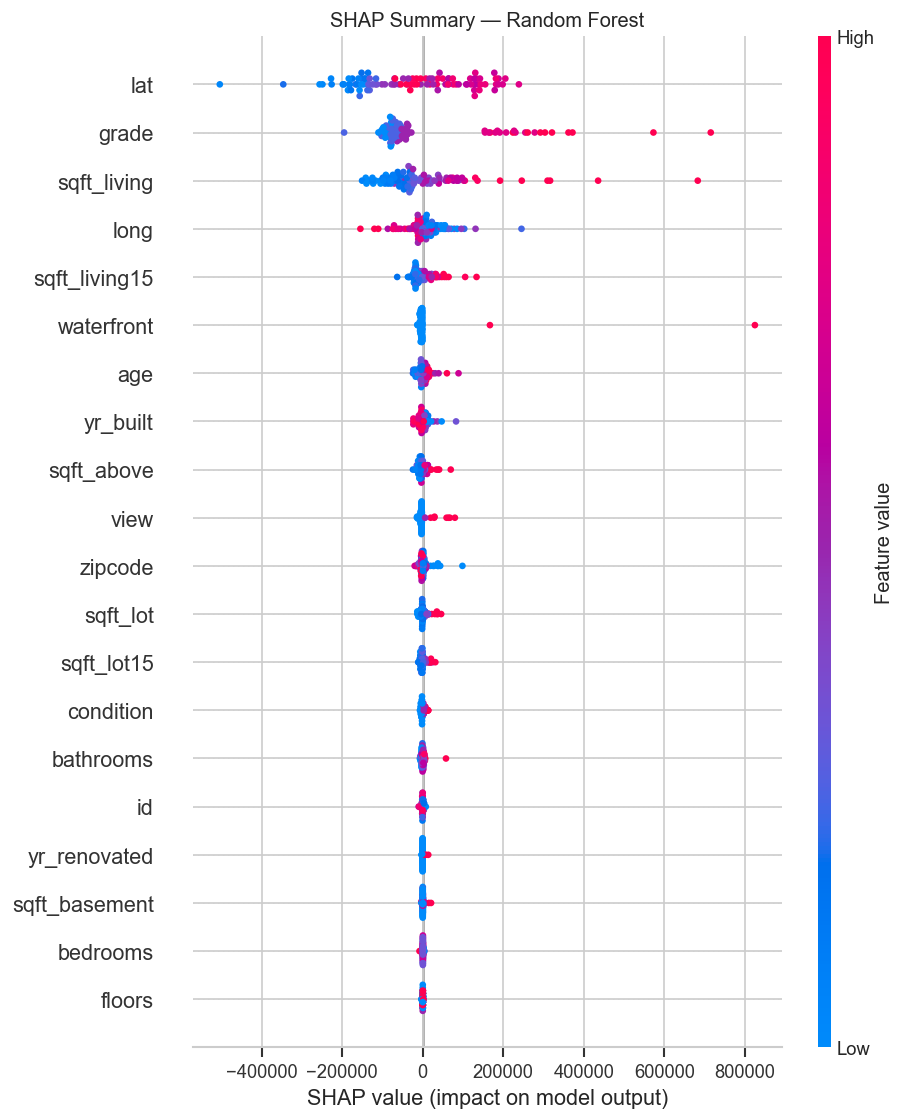

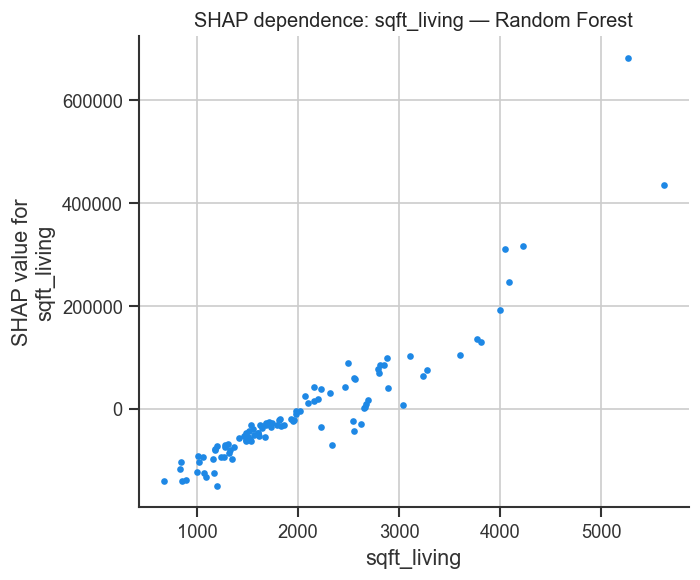

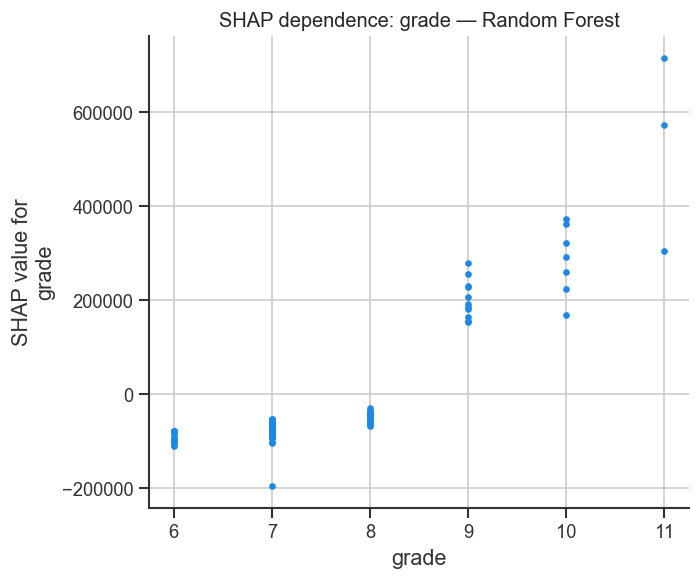

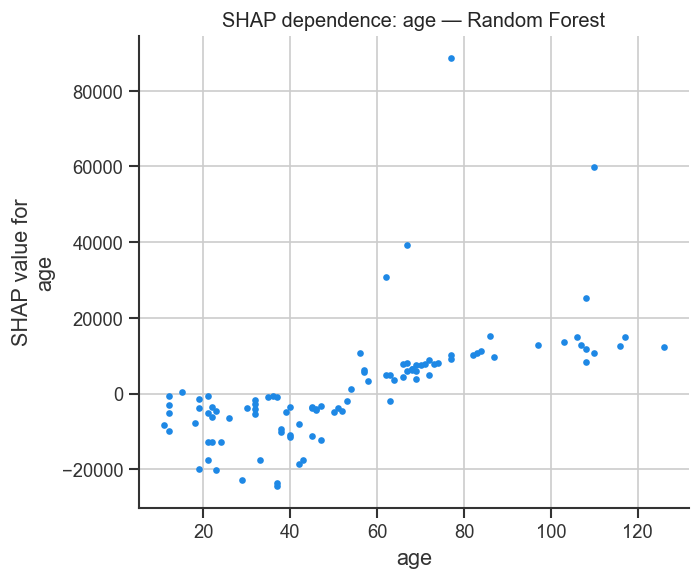

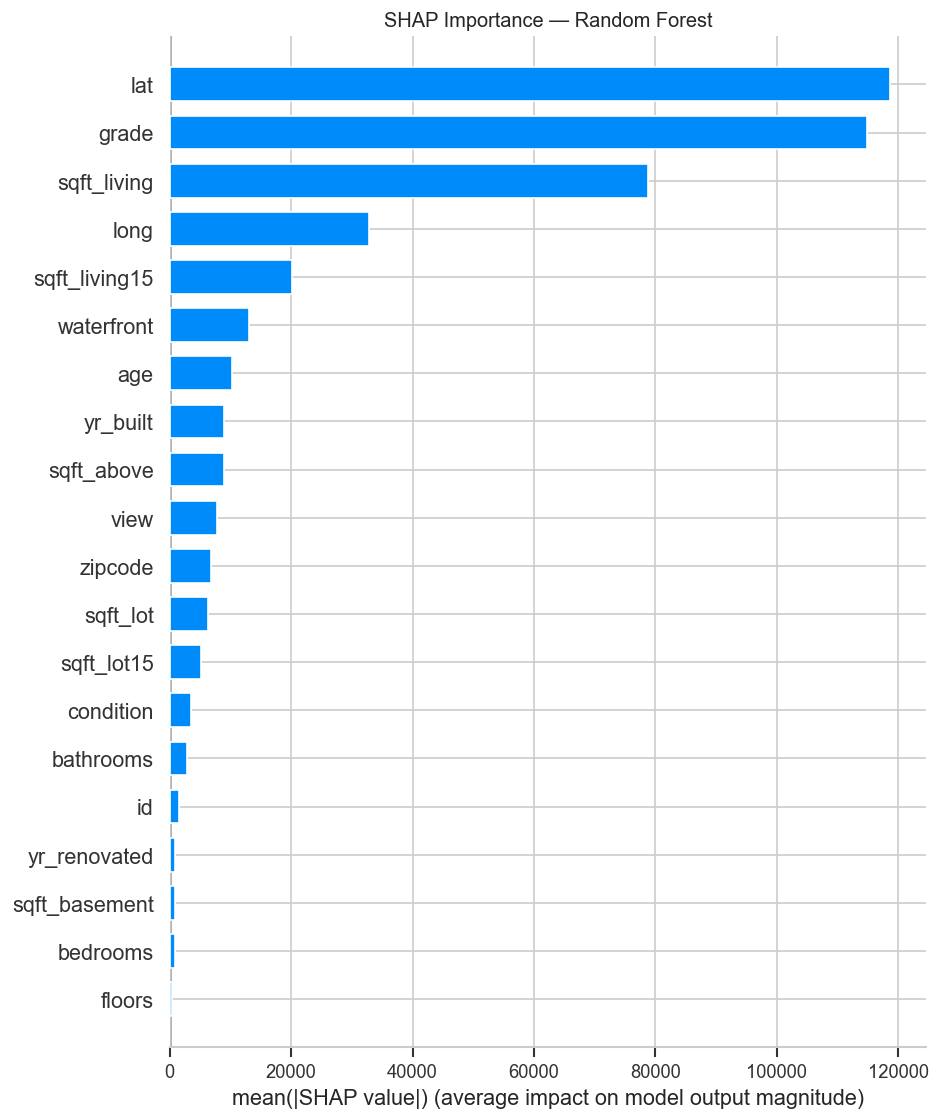

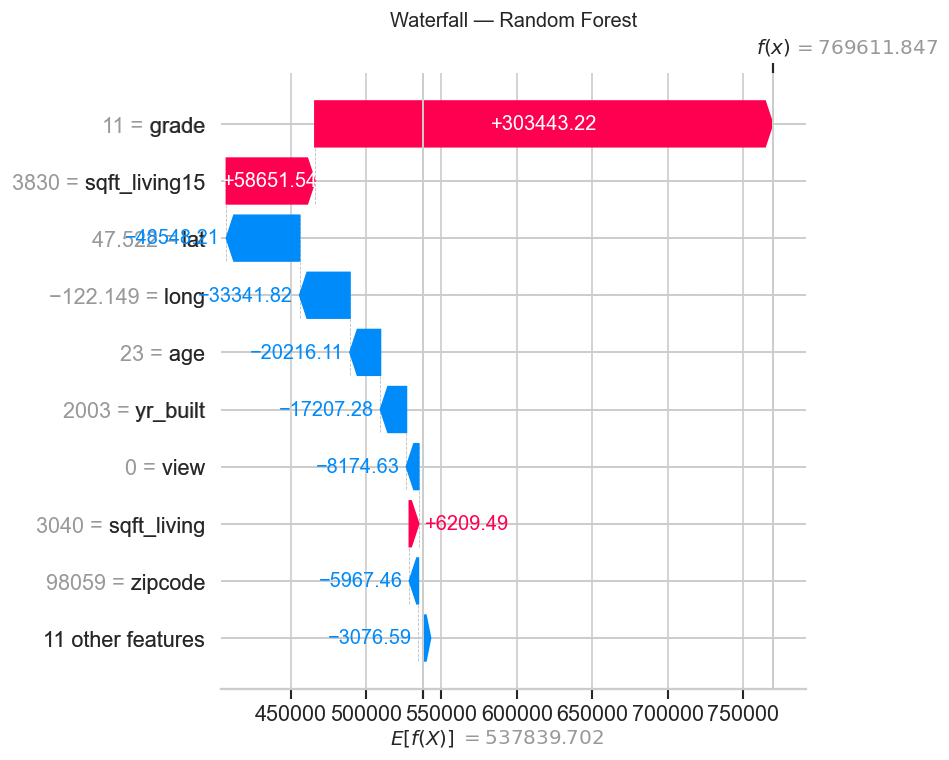

Top 3 features (global): [np.str_('lat'), np.str_('grade'), np.str_('sqft_living')]

SHAP pentru regresie: XGBoost


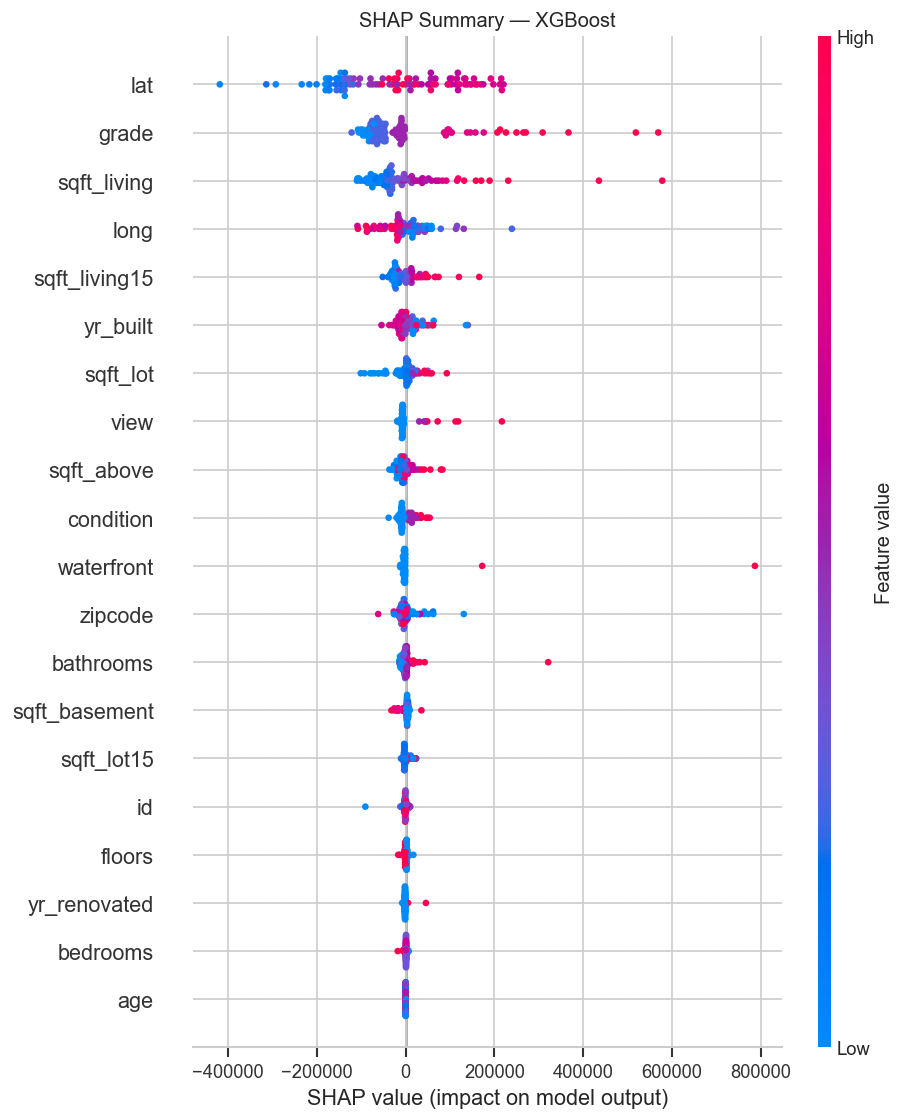

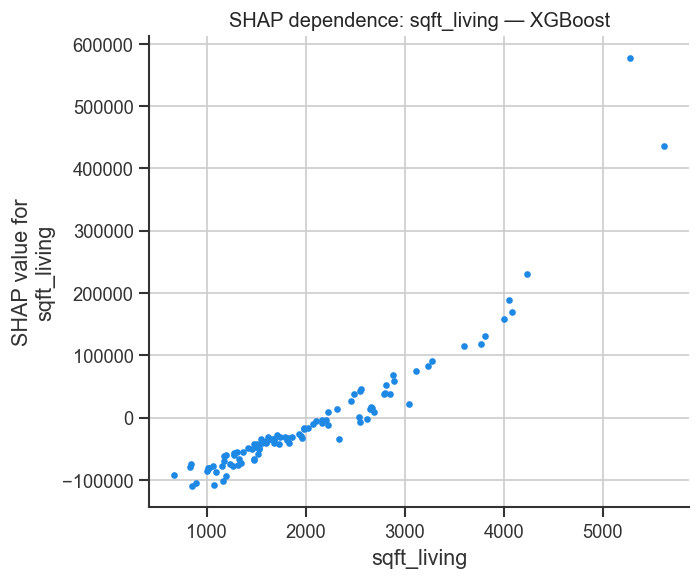

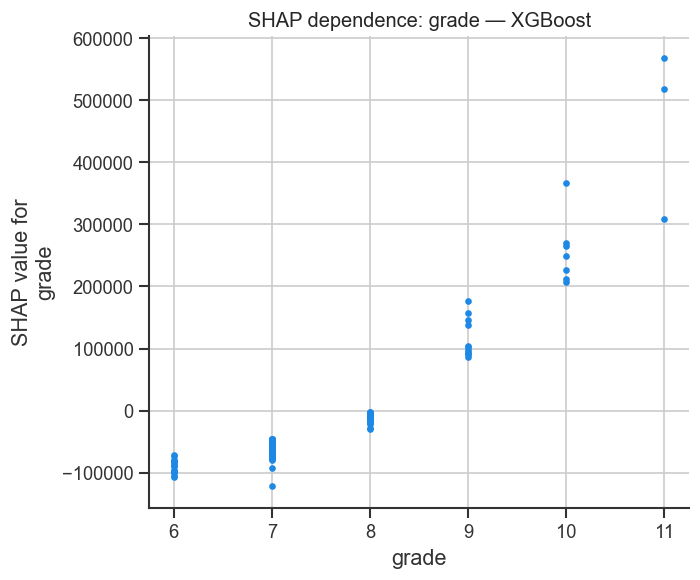

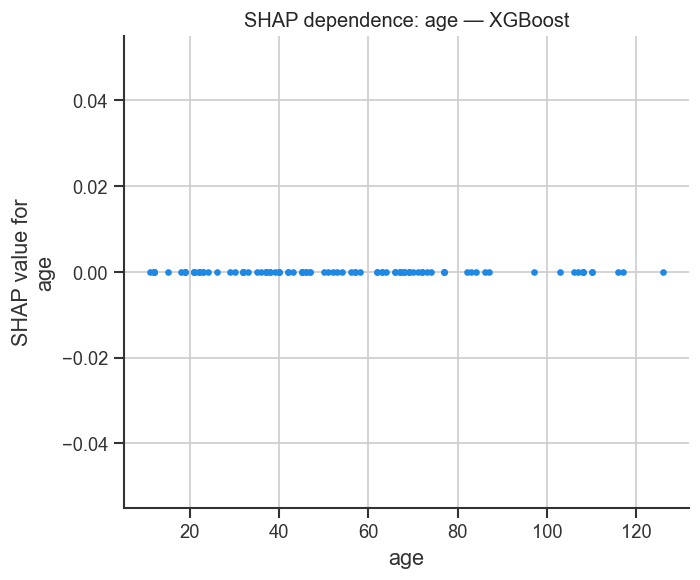

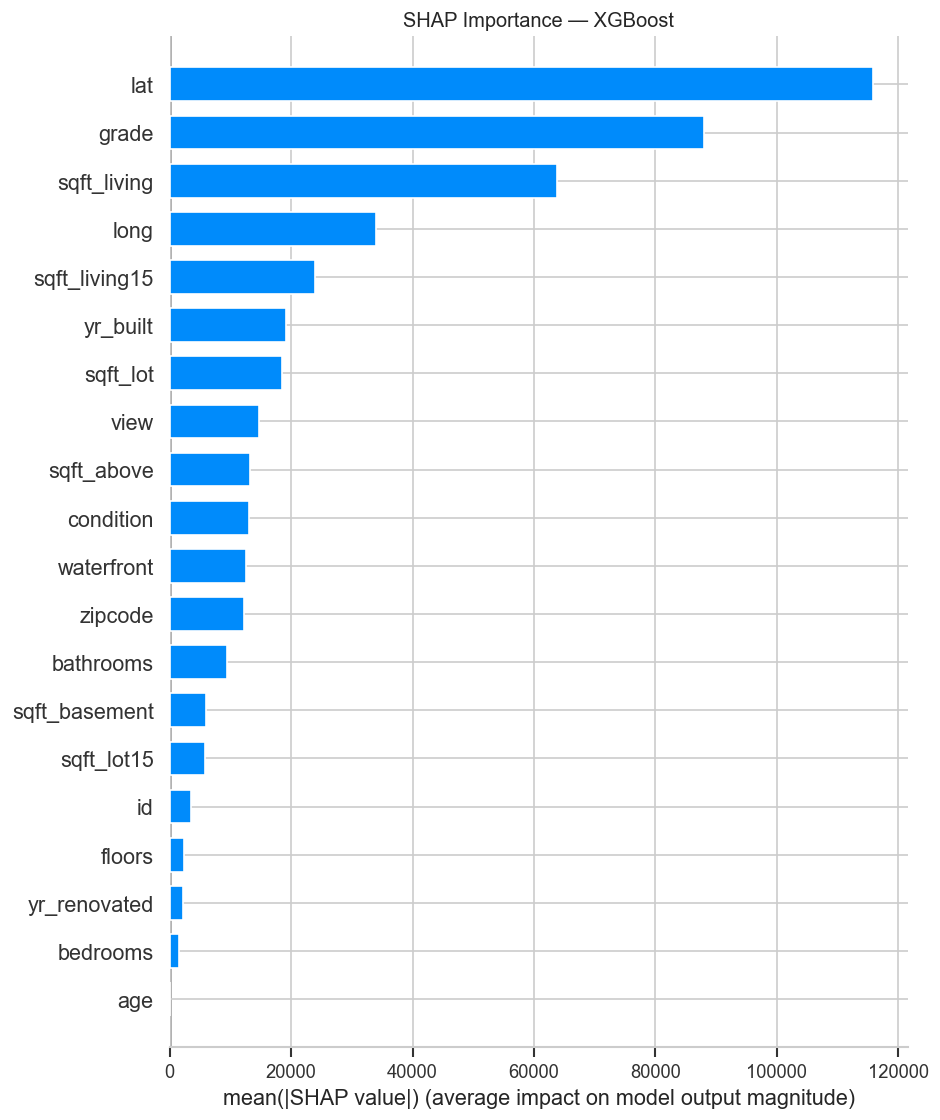

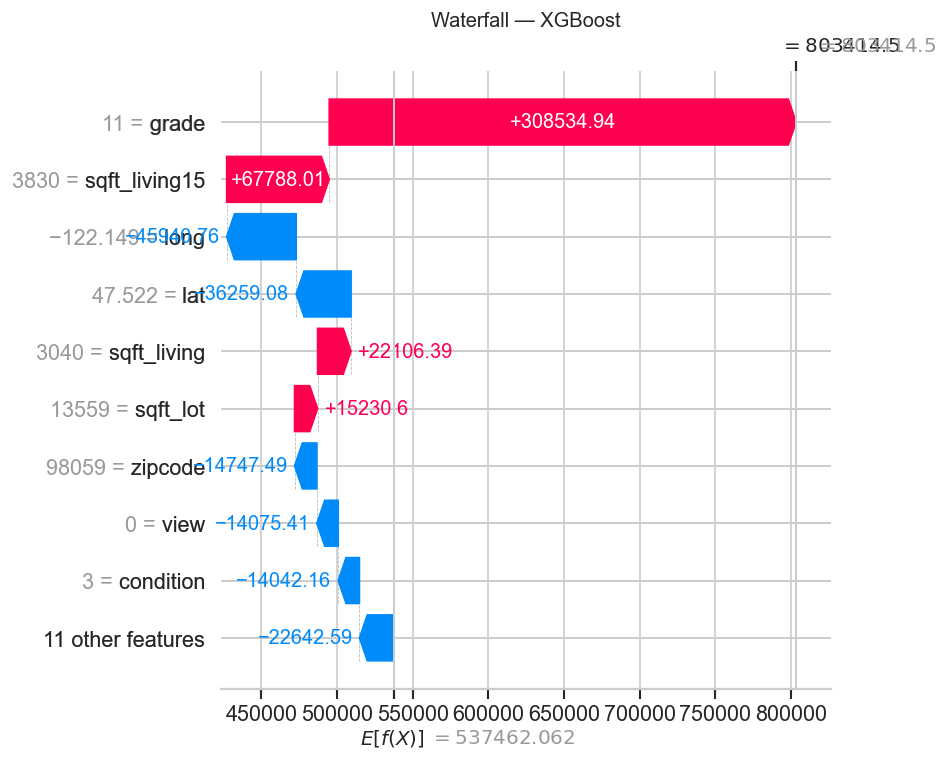

Top 3 features (global): [np.str_('lat'), np.str_('grade'), np.str_('sqft_living')]


In [8]:
top3_reg = list(tuned_reg.items())[:3]
feature_names = X.columns.tolist()

shap.initjs()

for name, (model, needs_scaling) in top3_reg:
    print(f"\n{'='*50}")
    print(f"SHAP pentru regresie: {name}")

    X_te = X_test_sc if needs_scaling else X_test.values
    X_te_df = pd.DataFrame(X_te, columns=feature_names)

    X_shap = X_te_df.sample(min(100, len(X_te_df)), random_state=42).reset_index(drop=True)

    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_shap, check_additivity=False)
    except Exception:
        explainer = shap.Explainer(model, X_shap)
        shap_values = explainer(X_shap)

    sv = shap_values.values

    shap.summary_plot(sv, X_shap, show=False)
    plt.title(f'SHAP Summary — {name}')
    plt.tight_layout()
    plt.savefig(f'../plots/reg_shap_summary_{name.replace(" ", "_")}.png')
    plt.show()

    features_of_interest = ['sqft_living', 'grade', 'age']
    for feat in features_of_interest:
        shap.dependence_plot(feat, sv, X_shap, interaction_index=None, show=False)
        plt.title(f'SHAP dependence: {feat} — {name}')
        plt.tight_layout()
        plt.savefig(f'../plots/reg_shap_scatter_{feat}_{name.replace(" ", "_")}.png')
        plt.show()

    shap.summary_plot(sv, X_shap, plot_type='bar', show=False)
    plt.title(f'SHAP Importance — {name}')
    plt.tight_layout()
    plt.savefig(f'../plots/reg_shap_bar_{name.replace(" ", "_")}.png')
    plt.show()

    base_val = shap_values.base_values
    if isinstance(base_val, np.ndarray):
        base_val = base_val[0] if base_val.ndim > 0 else base_val

    sv_single = sv[0] if sv.ndim == 2 else sv[0, :, 0]

    exp = shap.Explanation(
        values=sv_single,
        base_values=base_val,
        data=X_shap.iloc[0],
        feature_names=feature_names
    )
    shap.plots.waterfall(exp, show=False)
    plt.title(f'Waterfall — {name}')
    plt.tight_layout()
    plt.savefig(f'../plots/reg_shap_waterfall_{name.replace(" ", "_")}.png')
    plt.show()

    force_plot = shap.force_plot(base_val, sv_single, X_shap.iloc[0],
                                 matplotlib=False, show=False)
    shap.save_html(f'../plots/reg_shap_force_{name.replace(" ", "_")}.html', force_plot)
    from IPython.display import HTML, display
    display(HTML(force_plot.html()))

    mean_abs = np.abs(sv).mean(axis=0)
    top3_feat = np.array(feature_names)[np.argsort(mean_abs)[::-1][:3]]
    print("Top 3 features (global):", list(top3_feat))
    print("="*50)

### Interpretare SHAP – direcția influenței

- **sqft_living (suprafața locuibilă):** Valorile mari (peste 2000 sqft) au SHAP pozitiv, adică cresc prețul estimat. Valorile mici scad prețul.
- **grade (calitatea construcției):** O creștere a notei (de exemplu de la 7 la 10) duce la o creștere accentuată a prețului – relație puternic neliniară, vizibilă în scatter plot.
- **age (vârsta casei):** Efect mixt: casele foarte noi (age < 5 ani) și casele istorice (age > 80 ani) tind să aibă SHAP pozitiv, în timp ce casele cu vârstă medie (30–50 ani) au SHAP negativ (scad prețul).

In [9]:
for name, (model, needs_sc_flag) in trained_reg.items():
    fname = f'../models/reg_{name.replace(" ","_").lower()}_tuned.pkl'
    if not os.path.exists(fname):
        joblib.dump(model, fname)
        print(f"Salvat: {name}")

Salvat: Gaussian Process
